# Business Analytics Winter 2026

## Libraries 

In [109]:
# 1. Data Manipulation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Infrastructure & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 3. Regression Models (Part A)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# 4. Classification Models (Part B)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, 
                              GradientBoostingClassifier, 
                              AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# 5. Evaluation Metrics
# 5.1. Regression Metrics
from sklearn.metrics import (r2_score, 
                             mean_absolute_error, 
                             mean_squared_error)

# 5.2. Classification Metrics
from sklearn.metrics import (accuracy_score, 
                             precision_score, 
                             recall_score, 
                             f1_score, 
                             roc_auc_score, 
                             confusion_matrix, 
                             precision_recall_curve, 
                             roc_curve)

## Read data

In [110]:
raw_data = pd.read_csv('BUSI650_Healthcare_Dataset.csv')
raw_data.head()

,patient_id,age,sex,charlson_index,comorbidity_index,primary_diagnosis,length_of_stay,procedures_count,prior_admissions_12mo,discharge_disposition,insurance_type,lab_abnormality_score,smoking_status,bmi,systolic_bp,diastolic_bp,heart_rate,readmitted_30d,total_cost
0,10001,70,F,1,1,Pneumonia,2.6,1,0,Home with HomeCare,Public,0.89,Former,39.1,136.0,76.0,54.0,0,6067.32
1,10002,60,F,0,1,GI Bleed,6.7,5,1,Home with HomeCare,Private,1.07,Never,40.3,90.0,93.0,86.0,0,13445.66
2,10003,72,M,3,3,Diabetes Complications,10.7,2,0,Home with HomeCare,Public,1.34,Current,28.7,134.0,70.0,94.0,0,16129.78
3,10004,86,M,2,3,Sepsis,6.2,1,0,Home,Public,1.73,Former,24.1,107.0,95.0,81.0,1,14229.88
4,10005,58,F,0,1,GI Bleed,1.0,1,2,Home,Private,-0.72,Former,17.0,132.0,66.0,56.0,0,5323.01


In [111]:
X = raw_data.drop(['readmitted_30d', 'total_cost'], axis = 1)
y_regression = raw_data[['total_cost']]
y_classification = raw_data[['readmitted_30d']]

In [112]:
raw_regression_df = pd.concat([X, y_regression], axis=1)

# Part A — Regression (Cost Forecasting)

## 1. Business Problem Definition 
One of the most difficult things that hospitals face is the increase in healthcare costs, and the necessity of keeping the quality of care at the same time. Without an accurate expected treatment cost for the patient, the hospital budget overruns, the staffing is wrongly allocated, and the contracts with the insurers are unfavourable.
The purpose of this regression model is to predict early in admission the expected patient cost using demographic, clinical, and utilization data. The forecast will support the CFO and the contractors' team in improving annual budget accuracy, allocating staffing and resources based on patient risk, and identifying opportunities to renegotiate to reduce under-reimbursement.


## 2 Exploratory Data Analysis (EDA)

In [165]:
print(
    f"The dataset splited contains:\n"
    f"- {raw_regression_df.shape[0]} rows.\n"
    f"- {raw_regression_df.shape[1]} columns."
)

The dataset splited contains:
- 1000 rows.
- 18 columns.


In [166]:
# Missing Values
print(f"There is {raw_regression_df.isnull().sum().sum()} missing values in the dataset.\n\n")
raw_regression_df.info()


There is 0 missing values in the dataset.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             1000 non-null   int64  
 1   age                    1000 non-null   int64  
 2   sex                    1000 non-null   object 
 3   charlson_index         1000 non-null   int64  
 4   comorbidity_index      1000 non-null   int64  
 5   primary_diagnosis      1000 non-null   object 
 6   length_of_stay         1000 non-null   float64
 7   procedures_count       1000 non-null   int64  
 8   prior_admissions_12mo  1000 non-null   int64  
 9   discharge_disposition  1000 non-null   object 
 10  insurance_type         1000 non-null   object 
 11  lab_abnormality_score  1000 non-null   float64
 12  smoking_status         1000 non-null   object 
 13  bmi                    1000 non-null   float64
 14  systolic_bp  

In [115]:
# Unique Values
raw_regression_df.nunique().sort_values(ascending=False)

patient_id               1000
total_cost               1000
lab_abnormality_score     375
bmi                       219
length_of_stay            190
systolic_bp                85
age                        75
heart_rate                 65
diastolic_bp               60
comorbidity_index           9
primary_diagnosis           9
charlson_index              8
procedures_count            8
prior_admissions_12mo       6
discharge_disposition       5
insurance_type              3
smoking_status              3
sex                         2
dtype: int64

In [116]:
numerical_df = raw_regression_df.drop(["patient_id"], axis=1).select_dtypes(['int64', 'float64'])

skew = pd.DataFrame(numerical_df.apply(lambda x: x.skew())).T
variance = pd.DataFrame(numerical_df.var().round(2)).applymap(lambda x: "{:.{}f}".format(x, 2) if isinstance(x, (float)) else x).T
desc = pd.DataFrame(numerical_df.describe())

stats_df = pd.concat([desc, skew, variance]).T.reset_index()
stats_df.columns = ['atributos','count', 'mean', 'std','min', '25%', '50%', '75%', 'max', 'skew', 'variance']


print(
    """
    Insights:\n
    Some patients have an extremely high total cost. \n
    Supported by: Mean > Median (50% percentile), which indicates that the distribution is right-skewed.\n
    There may be some extreme values pulling the mean to the right.\n
    """ 
)

stats_df


    Insights:

    Some patients have an extremely high total cost. 

    Supported by: Mean > Median (50% percentile), which indicates that the distribution is right-skewed.

    There may be some extreme values pulling the mean to the right.

    


,atributos,count,mean,std,min,25%,50%,75%,max,skew,variance
0,age,1000.0,62.18,15.313461,18.0,52.0,62.0,72.0,95.0,-0.0034,234.50
1,charlson_index,1000.0,2.003,1.391016,0.0,1.0,2.0,3.0,7.0,0.587157,1.93
2,comorbidity_index,1000.0,2.301,1.460319,0.0,1.0,2.0,3.0,8.0,0.560409,2.13
3,length_of_stay,1000.0,7.5903,4.592972,1.0,4.275,6.6,9.925,29.7,1.131363,21.10
4,procedures_count,1000.0,1.56,1.140921,0.0,1.0,1.0,2.0,7.0,0.781875,1.30
5,prior_admissions_12mo,1000.0,0.635,0.804003,0.0,0.0,0.0,1.0,5.0,1.194115,0.65
6,lab_abnormality_score,1000.0,1.09898,1.11075,-1.0,0.4,1.01,1.83,5.64,0.484773,1.23
7,bmi,1000.0,28.1119,5.350452,17.0,24.1,28.2,31.8,44.3,-0.015057,28.63
8,systolic_bp,1000.0,120.957,17.941545,85.0,108.0,121.0,133.25,191.0,0.101623,321.90
9,diastolic_bp,1000.0,75.711,11.816053,50.0,68.0,76.0,84.0,115.0,0.048807,139.62


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 800x600 with 0 Axes>

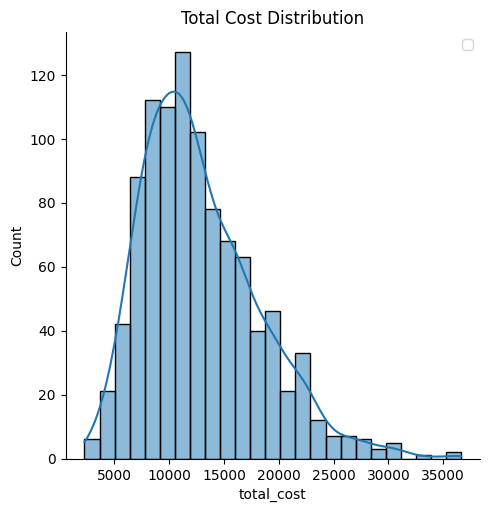

In [118]:
plt.figure(figsize=(8, 6))

sns.displot(raw_regression_df['total_cost'], kde=True)

plt.title('Total Cost Distribution')
plt.legend()

plt.show()

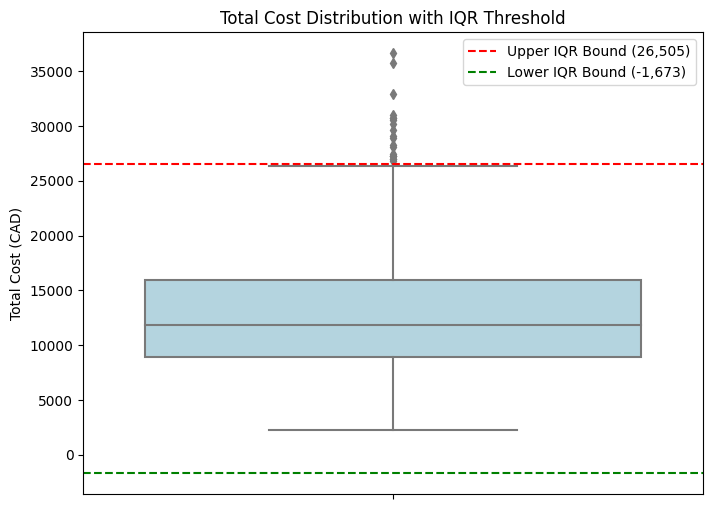

Upper Bound: 26505.25
Number of High-Cost Outliers: 20
Percentage of Dataset: 2.0 %
Outliers share of total cost: 4.61 %

      Insights:
      To find the outliers, I used the IQR method.
      - There are 20 outliers in the training dataset, which account for 2.0% of the dataset 
      - It represents 4.61% of the total cost.



In [167]:
plt.figure(figsize=(8, 6))

# Calculate IQR
Q1 = raw_regression_df['total_cost'].quantile(0.25)
Q3 = raw_regression_df['total_cost'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

sns.boxplot(data=raw_regression_df, y='total_cost', color='lightblue')

# Add IQR threshold lines
plt.axhline(upper_bound, color='red', linestyle='--', 
            label=f'Upper IQR Bound ({upper_bound:,.0f})')

plt.axhline(lower_bound, color='green', linestyle='--', 
            label=f'Lower IQR Bound ({lower_bound:,.0f})')

plt.title('Total Cost Distribution with IQR Threshold')
plt.ylabel('Total Cost (CAD)')
plt.legend()

plt.show()

# Print outlier summary
outliers = raw_regression_df[raw_regression_df['total_cost'] > upper_bound]

print("Upper Bound:", round(upper_bound,2))
print("Number of High-Cost Outliers:", len(outliers))
print("Percentage of Dataset:", round(len(outliers)/len(raw_regression_df)*100,2), "%")

top_outlier_cost = outliers['total_cost'].sum()
total_cost_sum = raw_regression_df['total_cost'].sum()

print("Outliers share of total cost:",
      round(top_outlier_cost / total_cost_sum * 100, 2), "%")

print(f"""
      Insights:
      To find the outliers, I used the IQR method.
      - There are {len(outliers)} outliers in the training dataset, which account for {round(len(outliers)/len(raw_regression_df)*100,2)}% of the dataset 
      - It represents {round(top_outlier_cost / total_cost_sum * 100, 2)}% of the total cost.
""")


    Insights:

    - length_of_stay has a strong positive correlation with total cost, which means length of stay is the most influencial predictor of total treament cost.

    - lab_abnormality_score is the second most influencial predictor of total treament cost. It may explained by abnormal lab results lead to more investigations, 
    and investigations need more time and resources.

    - procedure_count has a moderate impact on the total treatment cost.

    - charlson_index and comorbidity_score have a strong positive correlation, which may cause multicollinearity problem if both of them are included in the regression model.
    


<Axes: >

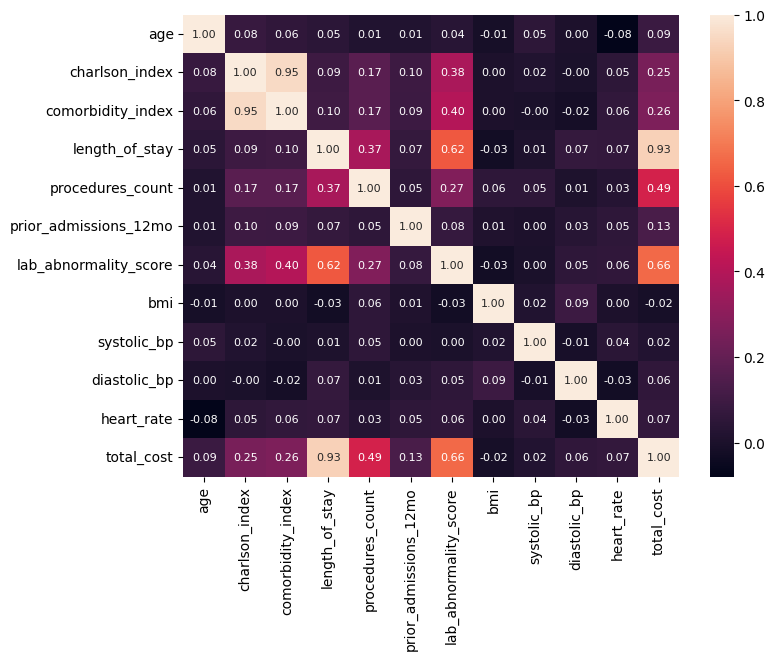

In [117]:
ax = plt.figure(figsize=(8, 6))

correlation_cols = raw_regression_df.drop(["patient_id"], axis=1).select_dtypes(include="number").columns

corr = raw_regression_df[correlation_cols].corr(method="pearson")


print(
    """
    Insights:\n
    - length_of_stay has a strong positive correlation with total cost, which means length of stay is the most influencial predictor of total treament cost.\n
    - lab_abnormality_score is the second most influencial predictor of total treament cost. It may explained by abnormal lab results lead to more investigations, 
    and investigations need more time and resources.\n
    - procedure_count has a moderate impact on the total treatment cost.\n
    Warning:
    - charlson_index and comorbidity_score have a strong positive correlation, which may cause multicollinearity problem if both of them are included in the regression model.
    """ 
)

sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 8})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


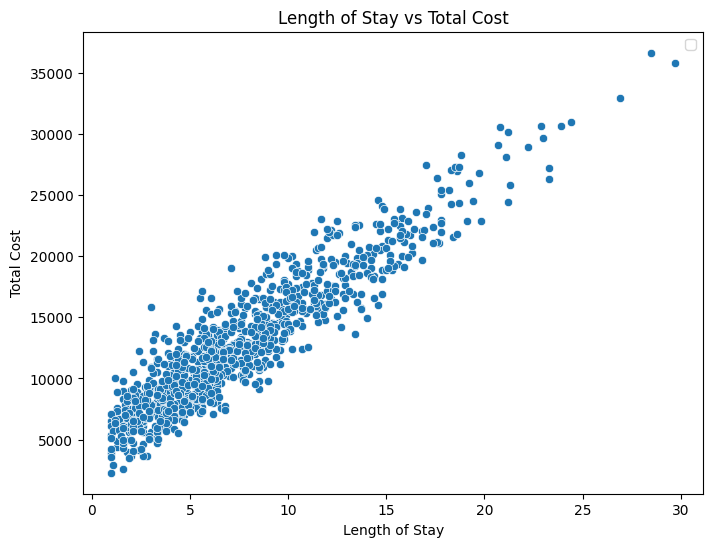

In [119]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='length_of_stay', y='total_cost', data=raw_regression_df)

plt.title('Length of Stay vs Total Cost')
plt.xlabel('Length of Stay')
plt.ylabel('Total Cost')
plt.legend()

plt.show()

## 3. Feature Engineering

#### Categorical
I need to treat the categorical variables because the model only accept numerical values.
All the categorical variables will be treated by using the One Hot Encode method because they don't have so many categories that could make the matrix esparce.


Variables:
- Sex -> Have 2 categories -> We will create 1 new column to represent its 2 categories.
- primary_diagnosis -> Have 9 categories -> We will create 8 new columns to represent its 9 categories.
- insurance_type -> Have 3 categories -> We will create 2 new columns to represent its 3 categories.
- smoking_status ->Have 3 categories -> We will create 2 new columns to represent its 3 categories.

In [121]:
categorical_df = raw_regression_df.drop(["patient_id"], axis=1).select_dtypes(['object'])
categorical_df

,sex,primary_diagnosis,discharge_disposition,insurance_type,smoking_status
0,F,Pneumonia,Home with HomeCare,Public,Former
1,F,GI Bleed,Home with HomeCare,Private,Never
2,M,Diabetes Complications,Home with HomeCare,Public,Current
3,M,Sepsis,Home,Public,Former
4,F,GI Bleed,Home,Private,Former
...,...,...,...,...,...
995,F,COPD,Home,Public,Never
996,F,Renal Failure,Home,Public,Current
997,F,COPD,Skilled Nursing Facility,Self-Pay,Never
998,F,Sepsis,Skilled Nursing Facility,Public,Former


In [122]:
categorical_df.groupby("sex").size().sort_values(ascending=False)

sex
F    509
M    491
dtype: int64

In [123]:
categorical_df.groupby("discharge_disposition").size().sort_values(ascending=False)

discharge_disposition
Home                        593
Home with HomeCare          182
Skilled Nursing Facility    143
Rehab                        65
Against Medical Advice       17
dtype: int64

In [168]:
categorical_df.groupby("primary_diagnosis").size().sort_values(ascending=False)

primary_diagnosis
Orthopedic                157
Heart Failure             131
Pneumonia                 125
Diabetes Complications    114
Renal Failure             110
COPD                      108
Sepsis                     96
GI Bleed                   88
Stroke/TIA                 71
dtype: int64

In [125]:
categorical_df.groupby("insurance_type").size().sort_values(ascending=False)

insurance_type
Public      635
Private     325
Self-Pay     40
dtype: int64

In [126]:
categorical_df.groupby("smoking_status").size().sort_values(ascending=False)

smoking_status
Former     424
Never      399
Current    177
dtype: int64

#### Exclude 
- De-identification: We will exclude patient_id because this is only an identification column.
- High correlation between independent variables: It is important to avoid multicollinearity. Between comorbidity_index and charlson_index, we will keep charlson_index because it is a well known cientific method.
- Ethics, Fairness, and Privacy: It is important to exclude some variables, such as , sex, to avoid increase the model's bias.
- Data Leakage: It is important to exclude discharge_disposition because this variable is only determined at the end of the patient stays, which means that including this variable would cause data leakage because the diposition already reflect the resources consumed.
- Even though age could increase bias, we will keep it because it is important for the hospital to understand the influence of age on the reimbursement contracts

In [127]:
# Exclusion
cols_to_exclude = ['patient_id', 'comorbidity_index', 'sex', 'discharge_disposition']

transformed_regression_df = raw_regression_df.drop(cols_to_exclude, axis=1)

# Encoding Categorical Variables
cols_to_encode = ['primary_diagnosis', 'insurance_type', 'smoking_status']
transformed_regression_df = pd.get_dummies(transformed_regression_df, columns=cols_to_encode, drop_first=True, dtype=int)
transformed_regression_df

,age,charlson_index,length_of_stay,procedures_count,prior_admissions_12mo,lab_abnormality_score,bmi,systolic_bp,diastolic_bp,heart_rate,...,primary_diagnosis_Heart Failure,primary_diagnosis_Orthopedic,primary_diagnosis_Pneumonia,primary_diagnosis_Renal Failure,primary_diagnosis_Sepsis,primary_diagnosis_Stroke/TIA,insurance_type_Public,insurance_type_Self-Pay,smoking_status_Former,smoking_status_Never
0,70,1,2.6,1,0,0.89,39.1,136.0,76.0,54.0,...,0,0,1,0,0,0,1,0,1,0
1,60,0,6.7,5,1,1.07,40.3,90.0,93.0,86.0,...,0,0,0,0,0,0,0,0,0,1
2,72,3,10.7,2,0,1.34,28.7,134.0,70.0,94.0,...,0,0,0,0,0,0,1,0,0,0
3,86,2,6.2,1,0,1.73,24.1,107.0,95.0,81.0,...,0,0,0,0,1,0,1,0,1,0
4,58,0,1.0,1,2,-0.72,17.0,132.0,66.0,56.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,58,2,3.9,0,1,1.16,35.0,120.0,62.0,88.0,...,0,0,0,0,0,0,1,0,0,1
996,91,0,10.0,1,2,1.52,22.4,100.0,59.0,86.0,...,0,0,0,1,0,0,1,0,0,0
997,72,0,7.9,3,3,2.31,29.7,139.0,70.0,89.0,...,0,0,0,0,0,0,0,1,0,1
998,53,1,10.3,3,0,2.62,34.2,133.0,54.0,72.0,...,0,0,0,0,1,0,1,0,1,0


In [128]:
transformed_regression_df.shape

(1000, 23)

## 4. Model

### Split data into train and test

In [129]:
X_regression = transformed_regression_df.drop(['total_cost'], axis = 1)
y_regression = transformed_regression_df[['total_cost']]

test_size = 0.3
seed = 42

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_regression, y_regression, test_size = test_size, random_state = seed)

print(f'X_train: {X_train_r.shape}')
print(f'y_train: {y_train_r.shape}')
print(f'X_test: {X_test_r.shape}')
print(f'y_test: {y_test_r.shape}')

X_train: (700, 22)
y_train: (700, 1)
X_test: (300, 22)
y_test: (300, 1)


#### Models and Evaluations

In [130]:
list_models = [
    LinearRegression(),
    Ridge(alpha=1.0),
    Lasso(alpha=1.0),
    ElasticNet(alpha=0.1),
    HuberRegressor(max_iter=1000),
    SVR(kernel='linear'), 
    DecisionTreeRegressor(max_depth=5),
    RandomForestRegressor(n_estimators=100, random_state=42),
    XGBRegressor(n_estimators=100, learning_rate=0.05)
]

list_models_names = [
    'Linear Regression',
    'Ridge (L2)',
    'Lasso (L1)',
    'ElasticNet',
    'Huber Regressor',
    'SVR Linear',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

In [ ]:
metric_list = []

for i in range(len(list_models)):

    numerical_transformer = Pipeline(steps=[
        ("scalar", StandardScaler())
    ])

    pipe = Pipeline(steps=[
        ("preprocessor", numerical_transformer),
        ("model", list_models[i])
    ])

    pipe.fit(X_train_r, y_train_r)

    y_pred_r = pipe.predict(X_test_r)

    r2 = r2_score(y_test_r, y_pred_r)
    mae = mean_absolute_error(y_test_r, y_pred_r)
    mse = mean_squared_error(y_test_r, y_pred_r)
    rmse = np.sqrt(mse)

    metric = {
        'Model': list_models_names[i],
        'R2': r2, 
        'MAE': mae, 
        'MSE': mse,
        'RMSE': rmse
    }

    metric_list.append(metric)

metric_df = pd.DataFrame(metric_list)

columns = ['Model', 'R2', 'MAE', 'MSE', 'RMSE']
metric_df = metric_df[columns]

metric_df

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


,Model,R2,MAE,MSE,RMSE
0,Linear Regression,0.917031,1208.825115,2.242781e+06,1497.591636
1,Ridge (L2),0.917156,1207.727528,2.239381e+06,1496.456087
2,Lasso (L1),0.917111,1208.351123,2.240609e+06,1496.866425
3,ElasticNet,0.918733,1190.309386,2.196766e+06,1482.149212
4,Huber Regressor,0.917151,1212.476042,2.239520e+06,1496.502471
5,SVR Linear,0.267100,3430.324581,1.981132e+07,4450.991174
6,Decision Tree,0.850758,1623.875676,4.034217e+06,2008.535951
7,Random Forest,0.895584,1360.780415,2.822501e+06,1680.029914
8,XGBoost,0.905092,1288.237753,2.565507e+06,1601.720042


In [176]:
print(
    f"""
       The Lasso (L1) Model will be the chosen model because:
        - It has high explainability, which is good to explain for managers
        - One of the top models regarding the metrics
        - R2 = {metric_df[metric_df["Model"] == "Lasso (L1)"]["R2"].values[0]} -> The model can explain {100 * metric_df[metric_df["Model"] == "Lasso (L1)"]["R2"].values[0]:.2f}% of the dependent variable
        - MAE = {metric_df[metric_df["Model"] == "Lasso (L1)"]["MAE"].values[0]} -> In average, the model prediction is wrong in about {metric_df[metric_df["Model"] == "Lasso (L1)"]["MAE"].values[0]:.2f} dolars per patient
        - RMSE = {metric_df[metric_df["Model"] == "Lasso (L1)"]["RMSE"].values[0]} -> RMSE close to MAE is a good sign of consistency.
 
    """
)



       The Lasso (L1) Model will be the chosen model because:
        - It has high explainability, which is good to explain for managers
        - One of the top models regarding the metrics
        - R2 = 0.9171108692562946 -> The model can explain 91.71% of the dependent variable
        - MAE = 1208.3511233962427 -> In average, the model prediction is wrong in about 1208.35 dolars per patient
        - RMSE = 1496.8664251369175 -> RMSE close to MAE is a good sign of consistency.
 
    


### Model Tuning

In [133]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 15, 20, 25, 100],
    'model__max_iter': [1000, 5000, 10000]
}

grid_lasso = GridSearchCV(
    pipe_lasso, 
    param_grid, 
    cv=5, 
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
    refit='r2', 
    return_train_score=True
)
grid_lasso.fit(X_train_r, y_train_r.values.ravel())

print(f"Best Alpha: {grid_lasso.best_params_}")
print(f"Best R2 on Train: {grid_lasso.best_score_}")
print(f"""
      The GridSearchCV was used to mitigate the overfitting problem of Lasso regression by tuning the alpha and max_iter hyperparameters.
      The best alpha found was {grid_lasso.best_params_['model__alpha']} and the best max_iter was {grid_lasso.best_params_['model__max_iter']}. 
      The best R2 score on the training set was {grid_lasso.best_score_:.4f}, which indicates that the model with these hyperparameters can explain approximately {grid_lasso.best_score_ * 100:.2f}% of the variance in the training data.
""")

Best Alpha: {'model__alpha': 25, 'model__max_iter': 1000}
Best R2 on Train: 0.9238023432035376

      The GridSearchCV was used to mitigate the overfitting problem of Lasso regression by tuning the alpha and max_iter hyperparameters.
      The best alpha found was 25 and the best max_iter was 1000. 
      The best R2 score on the training set was 0.9238, which indicates that the model with these hyperparameters can explain approximately 92.38% of the variance in the training data.



In [134]:
# Metrics on Test Set
y_pred_test_r = grid_lasso.predict(X_test_r)


r2_test = r2_score(y_test_r, y_pred_test_r)
mae_test = mean_absolute_error(y_test_r, y_pred_test_r)
rmse_test = np.sqrt(mean_squared_error(y_test_r, y_pred_test_r))


print(f"--- Final Lasso Performance (Test Set) ---")
print(f"R2 Score: {r2_test:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_test:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_test:.2f}")

# Train and test
print(f"\nOverfitting Check:")
print(f"R2 Train: {grid_lasso.best_score_:.4f}")
print(f"R2 Test: {r2_test:.4f}")
print(f"Difference: {abs(grid_lasso.best_score_ - r2_test):.4f}")

--- Final Lasso Performance (Test Set) ---
R2 Score: 0.9187
Mean Absolute Error (MAE): $1200.10
Root Mean Squared Error (RMSE): $1482.16

Overfitting Check:
R2 Train: 0.9238
R2 Test: 0.9187
Difference: 0.0051


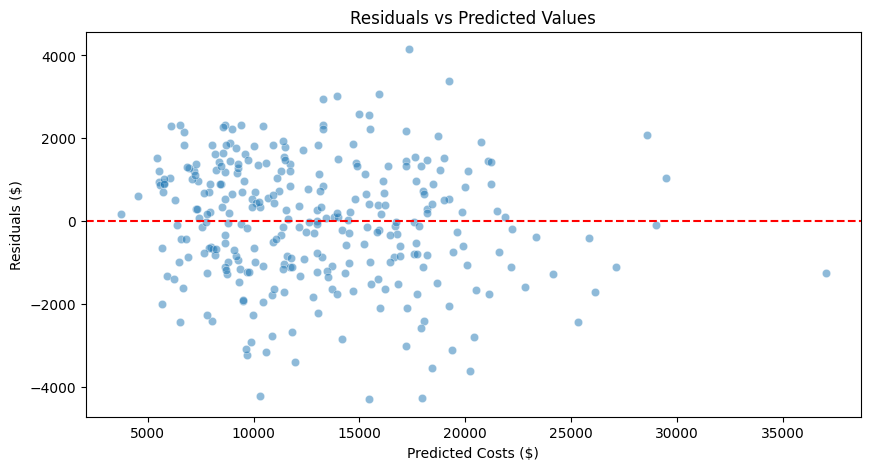

In [135]:
residuals = y_test_r.values.ravel() - y_pred_test_r

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_test_r, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Costs ($)')
plt.ylabel('Residuals ($)')
plt.show()

In [136]:

best_lasso = grid_lasso.best_estimator_

coefficients = best_lasso.named_steps['model'].coef_
feature_names = X_train_r.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance_df['Absolute_Impact'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Absolute_Impact', ascending=False)

print("Top 3 Cost Drivers:")
print(importance_df.head(3))

Top 3 Cost Drivers:
            Feature  Coefficient  Absolute_Impact
2    length_of_stay  4389.303397      4389.303397
3  procedures_count   742.601111       742.601111
1    charlson_index   612.802043       612.802043


## 5. Regression Conclusion and Insights

In [178]:
print(f"""
Based on the Lasso (L1) results, the top 3 impactful features are:
length_of_stay: 
This variable is the primary cost driver for the total treatment cost, with a coefficient of {importance_df[importance_df['Feature'] == 'length_of_stay']['Absolute_Impact'].values[0]:.2f}, which means that for each day the patient spends in the hospital, the total cost increases by $4389.30.
Action: Improving operational efficiency and discharge planning can reduce the number of days a patient is in the hospital, saving thousands of dollars.

procedures_count: 
For each procedure made, it will increase ${importance_df[importance_df['Feature'] == 'procedures_count']['Absolute_Impact'].values[0]:.2f} the total cost
Action: Implement and follow the protocols of resource utilization review

charlson_index: 
For each increase in the charlson_index, it will increase ${importance_df[importance_df['Feature'] == 'charlson_index']['Absolute_Impact'].values[0]:.2f} in the total cost
Action: This index can be a powerful tool for improving Risk-Adjusted Reimbursement. The manager can renegotiate higher reimbursements for patients who require higher costs proven by the model. 

Risks:
While reducing length_of_stay will save costs, it is essential that the medical staff ensure the patient's safety and stability, not only because of the patient's health, but also because there is a cost associated if the patient has to be readmitted to the hospital within 30 days.

These insights provide actionable data for help the CTO and managers refine the budget.
""")


Based on the Lasso (L1) results, the top 3 impactful features are:
length_of_stay: 
This variable is the primary cost driver for the total treatment cost, with a coefficient of 4389.30, which means that for each day the patient spends in the hospital, the total cost increases by $4389.30.
Action: Improving operational efficiency and discharge planning can reduce the number of days a patient is in the hospital, saving thousands of dollars.

procedures_count: 
For each procedure made, it will increase $742.60 the total cost
Action: Implement and follow the protocols of resource utilization review

charlson_index: 
For each increase in the charlson_index, it will increase $612.80 in the total cost
Action: This index can be a powerful tool for improving Risk-Adjusted Reimbursement. The manager can renegotiate higher reimbursements for patients who require higher costs proven by the model. 

Risks:
While reducing length_of_stay will save costs, it is essential that the medical staff ensure

# Part B — Classification (30-Day Readmission)

## 1. Business Problem Definition 

The healthcare industry follows strict regulations worldwide, and a high readmission rate within 30 days of discharge may indicate that a hospital is not providing high-quality care to its patients. This important metric is not only a sign of service quality, but it can also lead to penalties increasing the operational costs. The purpose of this model is to inform the hospital medical staff when a patient has a high risk of being readmitted in 30 days BEFORE they leave the hospital, so the staff can create a plan of interventions, ensuring patient safety and avoiding unnecessary penalties.

## 2. Exploratory Data Analysis (EDA)

In [138]:
raw_classification_df = pd.concat([X, y_classification], axis=1)
raw_classification_df

,patient_id,age,sex,charlson_index,comorbidity_index,primary_diagnosis,length_of_stay,procedures_count,prior_admissions_12mo,discharge_disposition,insurance_type,lab_abnormality_score,smoking_status,bmi,systolic_bp,diastolic_bp,heart_rate,readmitted_30d
0,10001,70,F,1,1,Pneumonia,2.6,1,0,Home with HomeCare,Public,0.89,Former,39.1,136.0,76.0,54.0,0
1,10002,60,F,0,1,GI Bleed,6.7,5,1,Home with HomeCare,Private,1.07,Never,40.3,90.0,93.0,86.0,0
2,10003,72,M,3,3,Diabetes Complications,10.7,2,0,Home with HomeCare,Public,1.34,Current,28.7,134.0,70.0,94.0,0
3,10004,86,M,2,3,Sepsis,6.2,1,0,Home,Public,1.73,Former,24.1,107.0,95.0,81.0,1
4,10005,58,F,0,1,GI Bleed,1.0,1,2,Home,Private,-0.72,Former,17.0,132.0,66.0,56.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10996,58,F,2,3,COPD,3.9,0,1,Home,Public,1.16,Never,35.0,120.0,62.0,88.0,0
996,10997,91,F,0,1,Renal Failure,10.0,1,2,Home,Public,1.52,Current,22.4,100.0,59.0,86.0,1
997,10998,72,F,0,0,COPD,7.9,3,3,Skilled Nursing Facility,Self-Pay,2.31,Never,29.7,139.0,70.0,89.0,1
998,10999,53,F,1,1,Sepsis,10.3,3,0,Skilled Nursing Facility,Public,2.62,Former,34.2,133.0,54.0,72.0,0


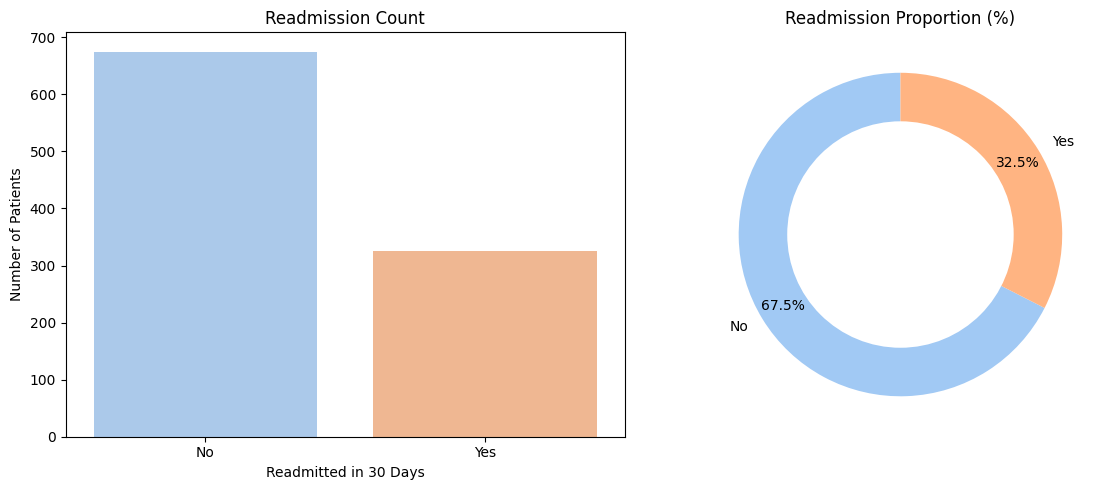

In [139]:
colors = sns.color_palette("pastel")[0:2]
labels = ['No', 'Yes']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar Plot
sns.countplot(data=raw_classification_df, x="readmitted_30d", palette=colors, ax=ax[0])
ax[0].set_title("Readmission Count")
ax[0].set_xticklabels(labels)
ax[0].set_xlabel("Readmitted in 30 Days")
ax[0].set_ylabel("Number of Patients")

# Pizza Plot
counts = raw_classification_df['readmitted_30d'].value_counts()
ax[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax[1].add_artist(centre_circle)
ax[1].set_title("Readmission Proportion (%)")

plt.tight_layout()
plt.show()

In [140]:
def plot_stacked_percentage(df, column, target='readmitted_30d'):
    cross_tab = pd.crosstab(df[column], df[target])
    
    cross_tab_prop = cross_tab.div(cross_tab.sum(1), axis=0) * 100
    
    ax = cross_tab_prop.plot(kind='bar', 
                             stacked=True, 
                             figsize=(12, 4), 
                             color=sns.color_palette("pastel")[0:2],
                             width=0.7)

    plt.title(f"Readmission Risk by {column} (%)", fontsize=14, fontweight='bold')
    plt.xlabel(column)
    plt.ylabel("Percentage of Patients (%)")
    plt.legend(title="Readmitted", labels=['No', 'Yes'], 
           bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.ylim(0, 110)

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 0:
            x, y = p.get_xy() 
            ax.text(x + width/2, 
                    y + height/2, 
                    f'{height:.1f}%', 
                    horizontalalignment='center', 
                    verticalalignment='center',
                    color='white',
                    fontweight='bold')

    plt.tight_layout()
    plt.show()


    Insights:
    - There may be an opportunity to review the process of discharge for patients with primary diagnosis of Sepsis, Heart Failure and Renal Failure because they have 
    a higher readmission risk.
    


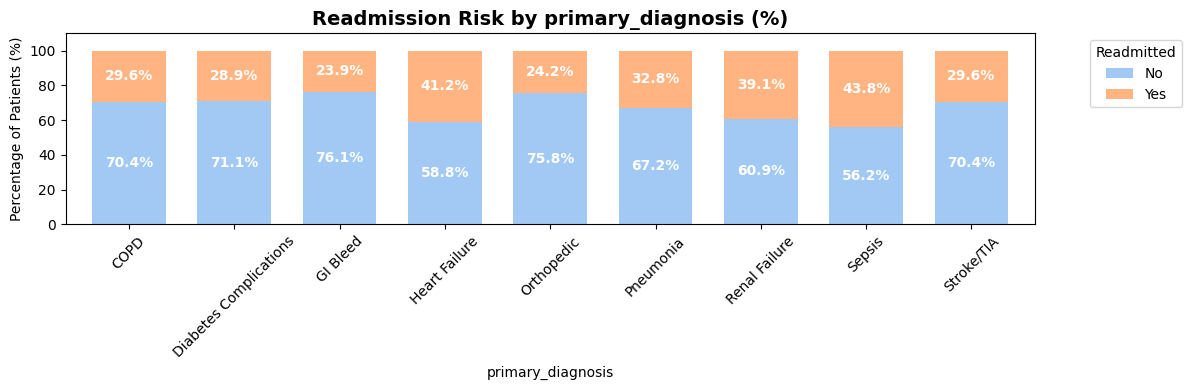

In [ ]:
print(
    f"""
    Insights:
    - There may be an opportunity to review the process of discharge for patients with primary diagnoses of Sepsis, Heart Failure and Renal Failure because they have 
    a higher readmission risk.
    """
)
plot_stacked_percentage(raw_classification_df, 'primary_diagnosis')


    Insights:
    - Patients with Private insurance have a higher readmission risk than those with Public and Self-Pay insurance, but they are very similar.
    


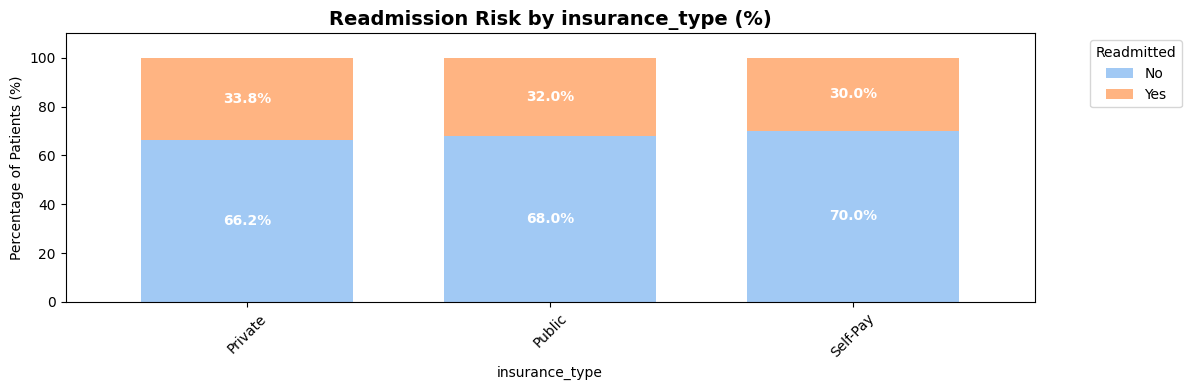

In [180]:
print(
    f"""
    Insights:
    - Patients with Private insurance have a higher readmission risk than those with Public and Self-Pay insurance, but they are very similar.
    """
)
plot_stacked_percentage(raw_classification_df, 'insurance_type')


    Insights:
    - Patients discharged against medical advice have a higher readmission risk, which may be explained by the fact that these patients leave before receiving the full treatment.
    - There may be an opportunity to review the process of discharge by the Skilled Nursing Facility because they have a higher readmission risk.

        


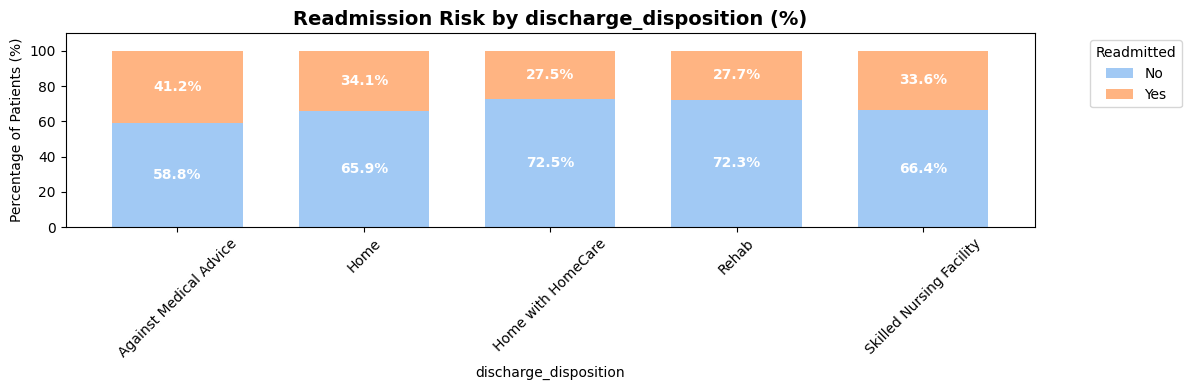

In [179]:
print(
    f"""
    Insights:
    - Patients discharged against medical advice have a higher readmission risk, which may be explained by the fact that these patients leave before receiving the full treatment.
    - There may be an opportunity to review the process of discharge by the Skilled Nursing Facility because they have a higher readmission risk.

        """
)
plot_stacked_percentage(raw_classification_df, 'discharge_disposition')


    Insights:
    - As expected, current smokers have a higher readmission risk, followed by former smokers and non-smokers.
    


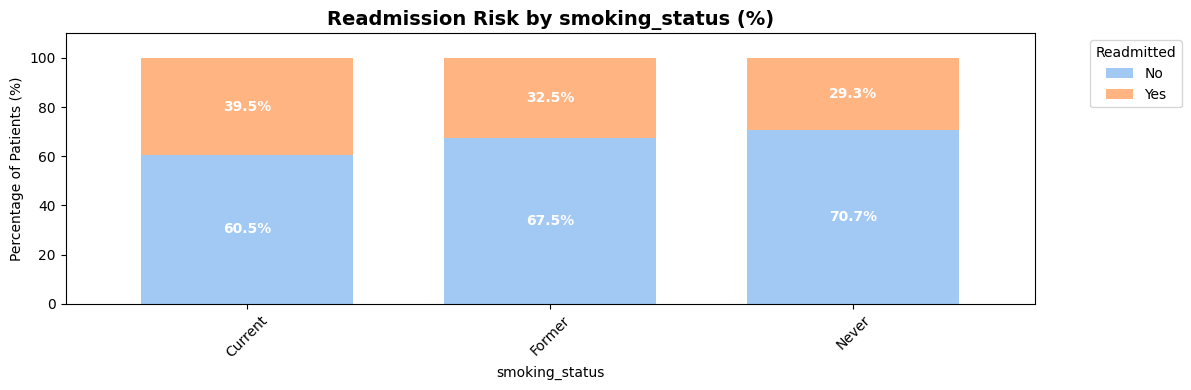

In [144]:
print(
    f"""
    Insights:
    - As expected, current smokers have a higher readmission risk, followed by former smokers and non-smokers.
    """
)
plot_stacked_percentage(raw_classification_df, 'smoking_status')

## 3. Feature Engineering

#### Exclude 
- De-identification: We will exclude patient_id because this is only an identification column.
- High correlation between independent variables: It is important to avoid multicollinearity. Between comorbidity_index and charlson_index, we will keep charlson_index because it is a well known cientific method.
- Ethics, Fairness, and Privacy: It is important to exclude some variables, such as , sex, to avoid increase the model's bias.
- discharge_disposition: As the classification model will be used to make prediction at the end of the patient treatment, we can use this feature in this model because we will have this information by this time.
- Even though age could increase bias, but we will keep it because it is important to the hospital understand the influence of age in the reimbursment contracts

In [145]:
# Exclusion
cols_to_exclude_class = ['patient_id', 'comorbidity_index', 'sex']

transformed_classification_df = raw_classification_df.drop(cols_to_exclude_class, axis=1)

cols_to_encode = ['primary_diagnosis', 'insurance_type', 'smoking_status', "discharge_disposition"]
transformed_classification_df = pd.get_dummies(transformed_classification_df, columns=cols_to_encode, drop_first=True, dtype=int)
transformed_classification_df

,age,charlson_index,length_of_stay,procedures_count,prior_admissions_12mo,lab_abnormality_score,bmi,systolic_bp,diastolic_bp,heart_rate,...,primary_diagnosis_Sepsis,primary_diagnosis_Stroke/TIA,insurance_type_Public,insurance_type_Self-Pay,smoking_status_Former,smoking_status_Never,discharge_disposition_Home,discharge_disposition_Home with HomeCare,discharge_disposition_Rehab,discharge_disposition_Skilled Nursing Facility
0,70,1,2.6,1,0,0.89,39.1,136.0,76.0,54.0,...,0,0,1,0,1,0,0,1,0,0
1,60,0,6.7,5,1,1.07,40.3,90.0,93.0,86.0,...,0,0,0,0,0,1,0,1,0,0
2,72,3,10.7,2,0,1.34,28.7,134.0,70.0,94.0,...,0,0,1,0,0,0,0,1,0,0
3,86,2,6.2,1,0,1.73,24.1,107.0,95.0,81.0,...,1,0,1,0,1,0,1,0,0,0
4,58,0,1.0,1,2,-0.72,17.0,132.0,66.0,56.0,...,0,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,58,2,3.9,0,1,1.16,35.0,120.0,62.0,88.0,...,0,0,1,0,0,1,1,0,0,0
996,91,0,10.0,1,2,1.52,22.4,100.0,59.0,86.0,...,0,0,1,0,0,0,1,0,0,0
997,72,0,7.9,3,3,2.31,29.7,139.0,70.0,89.0,...,0,0,0,1,0,1,0,0,0,1
998,53,1,10.3,3,0,2.62,34.2,133.0,54.0,72.0,...,1,0,1,0,1,0,0,0,0,1


In [146]:
transformed_classification_df.shape

(1000, 27)

## 4.  Model

### Split data into train and test

In [147]:
X_classification = transformed_classification_df.drop(['readmitted_30d'], axis = 1)
y_classification = transformed_classification_df[['readmitted_30d']]

test_size = 0.3
seed = 42

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_classification, y_classification, test_size = test_size, random_state = seed)

print(f'X_train: {X_train_c.shape}')
print(f'y_train: {y_train_c.shape}')
print(f'X_test: {X_test_c.shape}')
print(f'y_test: {y_test_c.shape}')

X_train: (700, 26)
y_train: (700, 1)
X_test: (300, 26)
y_test: (300, 1)


#### Models and Evaluations

We will use class_weight to deal with the imbalance in the variable

In [148]:
def func_class_weight(df, col_name):
    y_imb = df[col_name]

    class_freq = np.bincount(y_imb)
    class_sqrt_freq = np.sqrt(class_freq)
    class_weight = class_sqrt_freq.sum() / (class_freq * class_sqrt_freq)
    class_weight_dict = dict(enumerate(class_weight))

    return class_weight_dict

class_weight_dict = func_class_weight(y_train_c, "readmitted_30d")

In [ ]:
seed = 42

list_classification_models = [
    LogisticRegression(class_weight=class_weight_dict, random_state=seed, max_iter=1000),
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=seed),
    RandomForestClassifier(class_weight=class_weight_dict, random_state=seed, n_estimators=100,),
    SVC(kernel='rbf', class_weight=class_weight_dict, probability=True, random_state=seed),
    KNeighborsClassifier(),
    GaussianNB(),
    GradientBoostingClassifier(random_state=seed),
    AdaBoostClassifier(random_state=seed)
]

list_classification_names = [
    'Logistic Regression',
    'DecisionTree', 
    'RandomForest', 
    'SVC_rbf', 
    'KNN', 
    'GaussianNB',
    'GradientBoosting', 
    'AdaBoost'
]

In [150]:
classification_metrics = []

for i in range(len(list_classification_models)):
    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ("model", list_classification_models[i])
    ])

    
    pipeline.fit(X_train_c, y_train_c)

    
    y_pred = pipeline.predict(X_test_c)
    
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    rec = recall_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    
    
    y_proba = pipeline.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)

    
    conf_matrix = confusion_matrix(y_test_c, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()

    
    res = {
        "Model": list_classification_names[i],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC AUC": auc,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }
    
    classification_metrics.append(res)

df_results_class = pd.DataFrame(classification_metrics)
df_results_class = df_results_class.sort_values(by="Recall", ascending=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-pack

In [151]:
df_results_class

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,TP,FP,TN,FN
3,SVC_rbf,0.316667,0.316667,1.000000,0.481013,0.693710,95,205,0,0
0,Logistic Regression,0.550000,0.400990,0.852632,0.545455,0.698691,81,121,84,14
1,DecisionTree,0.653333,0.458716,0.526316,0.490196,0.619255,50,59,146,45
5,GaussianNB,0.680000,0.494737,0.494737,0.494737,0.658434,47,48,157,48
7,AdaBoost,0.666667,0.469880,0.410526,0.438202,0.663671,39,44,161,56
6,GradientBoosting,0.666667,0.465753,0.357895,0.404762,0.661053,34,39,166,61
2,RandomForest,0.693333,0.525424,0.326316,0.402597,0.686264,31,28,177,64
4,KNN,0.686667,0.509804,0.273684,0.356164,0.600000,26,25,180,69


The Logistic Regression Model will be the chosen model because:
- It has high explainability, which is good for managers to explain
- The model has one of the highest recall rates, which is the most important metric for the hospital case, because they need to know the patients who would be readmitted
so they can apply interventions to minimize the number of patients who are actually readmitted. 
For hospitals, the cost of False Negatives (patients who are readmitted but the model predicted they would not be) is much higher 
than the cost of False Positives (patients who are not readmitted but the model predicted they would be).

### Model Tuning

In [152]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight=class_weight_dict, random_state=seed, max_iter=1000))
])


param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear'] 
}


grid_lr = GridSearchCV(
    pipe_lr, 
    param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)


grid_lr.fit(X_train_c, y_train_c.values.ravel())

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best recall on training (CV): {grid_lr.best_score_:.4f}")

Best parameters: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best recall on training (CV): 0.5568


--- Tuned Model Performance ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,TP,FP,TN,FN
0,Logistic Regression (Tuned),0.59,0.417647,0.747368,0.535849,0.692837,71,99,106,24


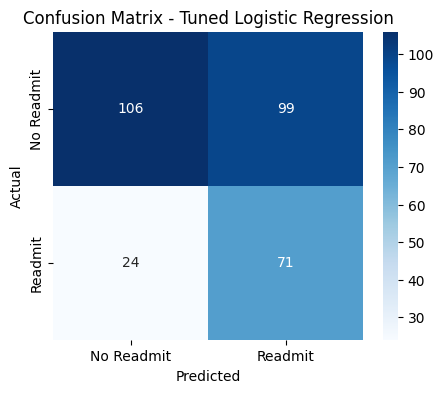

In [ ]:
best_lr_model = grid_lr.best_estimator_
y_pred_best = best_lr_model.predict(X_test_c)
y_proba_best = best_lr_model.predict_proba(X_test_c)[:, 1]


acc_best = accuracy_score(y_test_c, y_pred_best)
prec_best = precision_score(y_test_c, y_pred_best)
rec_best = recall_score(y_test_c, y_pred_best)
f1_best = f1_score(y_test_c, y_pred_best)
auc_best = roc_auc_score(y_test_c, y_proba_best)


tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred_best).ravel()


df_tuned_results = pd.DataFrame([{
    "Model": "Logistic Regression (Tuned)",
    "Accuracy": acc_best,
    "Precision": prec_best,
    "Recall": rec_best,
    "F1-Score": f1_best,
    "ROC AUC": auc_best,
    "TP": tp, "FP": fp, "TN": tn, "FN": fn
}])


print("--- Tuned Model Performance ---")
display(df_tuned_results)



plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_c, y_pred_best), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Readmit', 'Readmit'], yticklabels=['No Readmit', 'Readmit'])
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

After tuning, we have a more balanced model, but it is not the best model yet. To refine the model, we will change the standard decision threshold. Instead of assuming that when the probability is less than 50%, the class is 0, and when it is greater than or equal, the class is 1, we will find the best threshold based on financial metrics.

To define the financial metrics, we will assume that:
- Error type I (False Negative - when the model said the patient will not be readmitted, but the patient came back) = $12,000
- Error type II (False Positive - when the model said the patient will be readmitted, but the patient will not come back) = $150

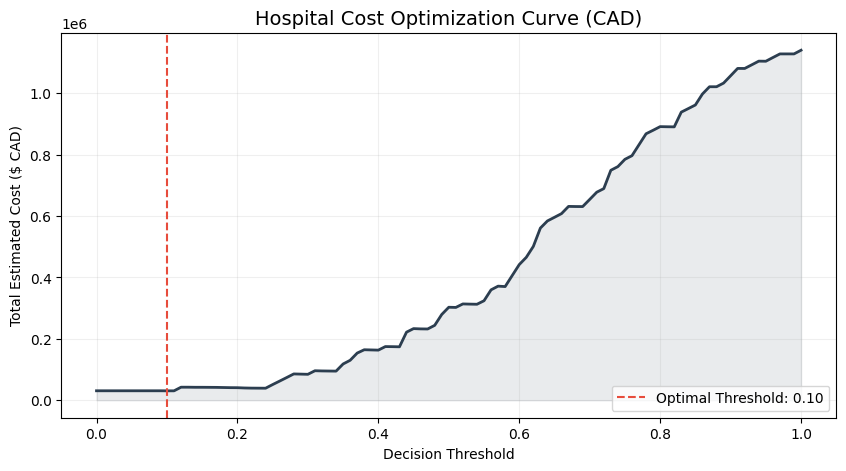

Optimal Threshold for Cost Minimization: 0.10
Projected Minimum Cost for this test set: $30,600.00 CAD


In [154]:
# Financial Cost Analysis
cost_fn = 12000
cost_fp = 150


y_proba = best_lr_model.predict_proba(X_test_c)[:, 1]


thresholds = np.linspace(0, 1, 101)
total_costs = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred_t).ravel()
    
    # (FNs * $12k) + (FPs * $150)
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    total_costs.append(total_cost)


best_idx = np.argmin(total_costs)
optimal_threshold = thresholds[best_idx]
min_cost = total_costs[best_idx]


plt.figure(figsize=(10, 5))
plt.plot(thresholds, total_costs, color='#2c3e50', linewidth=2)
plt.axvline(optimal_threshold, color='#e74c3c', linestyle='--', 
            label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.fill_between(thresholds, total_costs, alpha=0.1, color='#2c3e50')
plt.title("Hospital Cost Optimization Curve (CAD)", fontsize=14)
plt.xlabel("Decision Threshold")
plt.ylabel("Total Estimated Cost ($ CAD)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Optimal Threshold for Cost Minimization: {optimal_threshold:.2f}")
print(f"Projected Minimum Cost for this test set: ${min_cost:,.2f} CAD")

Cross Threshold: 0.6648
Cross Precision (P/R): 0.4632


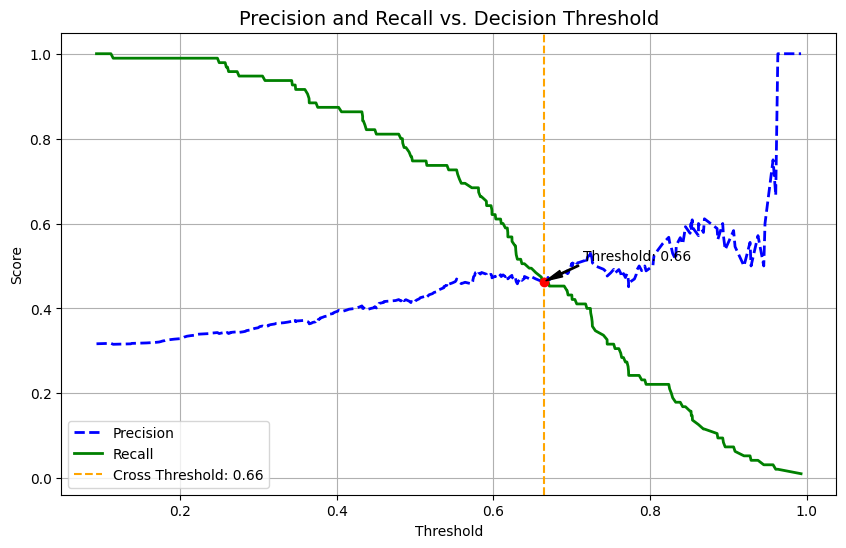

In [155]:
# Technical Analysis - Precision-Recall Curve
y_scores = best_lr_model.predict_proba(X_test_c)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test_c, y_scores)

diff = np.abs(precisions[:-1] - recalls[:-1])
cross_idx = np.argmin(diff)

cross_threshold = thresholds[cross_idx]
cross_precision = precisions[cross_idx]
cross_recall = recalls[cross_idx]

print(f"Cross Threshold: {cross_threshold:.4f}")
print(f"Cross Precision (P/R): {cross_precision:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)


plt.axvline(x=cross_threshold, color='orange', linestyle='--', 
            label=f'Cross Threshold: {cross_threshold:.2f}')


plt.plot(cross_threshold, cross_precision, 'ro') 


plt.annotate(f'Threshold: {cross_threshold:.2f}', 
             xy=(cross_threshold, cross_precision), 
             xytext=(cross_threshold + 0.05, cross_precision + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title("Precision and Recall vs. Decision Threshold", fontsize=14)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

--- Test Dataset Results ---

--- Threshold: 0.3 ---

--- Metrics with Threshold ---
Recall: 0.9474
Precision: 0.3557
F1-Score: 0.5172

--- Financial Simulation ---
Cost of undetected readmissions (FN): $60,000.00 CAD
Cost of preventive interventions (FP): $24,450.00 CAD
TOTAL ESTIMATED COST: $84,450.00 CAD


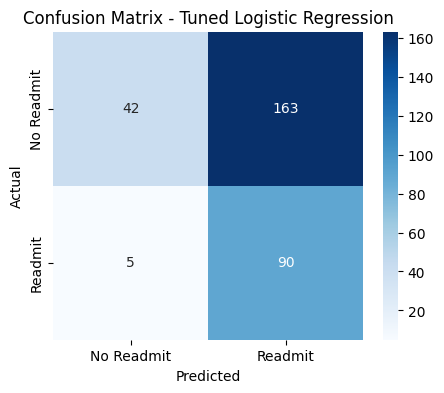

In [164]:
# Final Balance Analysis with Custom Threshold
custom_threshold = 0.3
y_pred_test_custom = (y_scores >= custom_threshold).astype(int)


print(f"--- Test Dataset Results ---")
print("")
print(f"--- Threshold: {custom_threshold} ---")
print("")
print(f"--- Metrics with Threshold ---")
print(f"Recall: {recall_score(y_test_c, y_pred_test_custom):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_test_custom):.4f}")
print(f"F1-Score: {f1_score(y_test_c, y_pred_test_custom):.4f}")

# Assunptions for Cost Analysis
cost_fn = 12000 
cost_fp = 150   

fn_custom = confusion_matrix(y_test_c, y_pred_test_custom)[1][0]
fp_custom = confusion_matrix(y_test_c, y_pred_test_custom)[0][1]

total_cost_custom = (fn_custom * cost_fn) + (fp_custom * cost_fp)
print("")
print(f"--- Financial Simulation ---")
print(f"Cost of undetected readmissions (FN): ${fn_custom * cost_fn:,.2f} CAD")
print(f"Cost of preventive interventions (FP): ${fp_custom * cost_fp:,.2f} CAD")
print(f"TOTAL ESTIMATED COST: ${total_cost_custom:,.2f} CAD")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_c, y_pred_test_custom), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Readmit', 'Readmit'], yticklabels=['No Readmit', 'Readmit'])
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

ROC-AUC Score: 0.6928


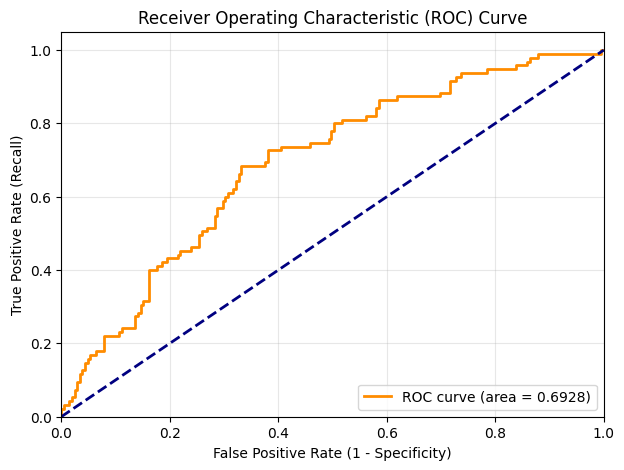

In [157]:
roc_auc = roc_auc_score(y_test_c, y_scores)

fpr, tpr, thresholds = roc_curve(y_test_c, y_scores)

print(f"ROC-AUC Score: {roc_auc:.4f}")


plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Trade-off Analysis: Safety x Costs


The cost analysis suggests a threshold of 10%, but it will affect patient safety.

The technical analysis suggests a threshold of 66%, but it will increase the costs.


To balance patient safety and costs, we will use a threshold of 30%. With it, we can achieve a Recall of 94.74% ensuring that almost all patients at risk of readmission are captured. On the other side, we will accept the cost of a higher rate of False Positives (interventions for patients that will not be readmitted) because its cost is significantly lower than the cost of readmission.


Financial Impact Simulation:

Out of 1000, 95 patients will be readmitted. Comparing scenarios:

| Scenario | Strategy | Estimated Cost | Patient Risk |

| Current | Nothing | 95 x $12,000 = $1,140,000 | High |

| Proposed | Model | (5 x $12,000) + (163 x $150) = $84,450 | Low |



To conclude, implementing this model results in a total estimated saving of $1,055,550, representing more than 92.6% in readmission-related costs. This strategy helps the hospitals to shift their strategy from reactive to active, and also improves their service quality.

# Add Predictions to the original dataset

In [158]:
regression_train = pd.concat([X_train_r.reset_index(drop=True), y_train_r.reset_index(drop=True)], axis=1)
regression_train["train_test_flag"] = "train"
regression_test = pd.concat([X_test_r.reset_index(drop=True), y_test_r.reset_index(drop=True)], axis=1)
regression_test["train_test_flag"] = "test"
regression_test["total_cost_predicted"] = y_pred_test_r

regression_final_dataset = pd.concat([regression_train, regression_test], axis=0).reset_index(drop=True)
regression_final_dataset



,age,charlson_index,length_of_stay,procedures_count,prior_admissions_12mo,lab_abnormality_score,bmi,systolic_bp,diastolic_bp,heart_rate,...,primary_diagnosis_Renal Failure,primary_diagnosis_Sepsis,primary_diagnosis_Stroke/TIA,insurance_type_Public,insurance_type_Self-Pay,smoking_status_Former,smoking_status_Never,total_cost,train_test_flag,total_cost_predicted
0,44,2,7.7,2,1,-0.19,36.3,104.0,75.0,90.0,...,1,0,0,1,0,1,0,10241.83,train,NaN
1,68,4,7.5,1,0,2.31,31.6,141.0,82.0,93.0,...,1,0,0,1,0,0,1,14380.53,train,NaN
2,36,2,6.9,2,0,1.12,22.8,122.0,79.0,73.0,...,0,1,0,0,0,1,0,12279.98,train,NaN
3,58,3,7.6,7,0,1.14,32.9,137.0,73.0,92.0,...,0,0,0,1,0,0,1,16102.67,train,NaN
4,61,3,4.0,3,0,-0.15,23.8,134.0,82.0,76.0,...,0,0,0,0,0,0,1,11801.43,train,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,54,1,4.7,0,0,0.69,18.5,112.0,66.0,56.0,...,0,0,0,1,0,0,1,8855.51,test,7959.282529
996,54,2,5.7,1,0,0.22,32.3,139.0,63.0,75.0,...,0,0,0,1,0,1,0,10258.18,test,9910.208066
997,79,1,14.0,1,1,0.90,30.4,136.0,96.0,63.0,...,0,0,0,0,0,1,0,18640.16,test,17674.745606
998,74,2,17.8,2,0,3.13,29.8,120.0,57.0,67.0,...,0,0,0,1,0,0,1,22965.18,test,23350.921962


In [159]:
classification_train = pd.concat([X_train_c.reset_index(drop=True), y_train_c.reset_index(drop=True)], axis=1)
classification_train["train_test_flag"] = "train"
classification_test = pd.concat([X_test_c.reset_index(drop=True), y_test_c.reset_index(drop=True)], axis=1)
classification_test["train_test_flag"] = "test"
classification_test["readmission_30d_predictied"] = y_pred_test_custom

classification_final_dataset = pd.concat([classification_train, classification_test], axis=0).reset_index(drop=True)
classification_final_dataset


,age,charlson_index,length_of_stay,procedures_count,prior_admissions_12mo,lab_abnormality_score,bmi,systolic_bp,diastolic_bp,heart_rate,...,insurance_type_Self-Pay,smoking_status_Former,smoking_status_Never,discharge_disposition_Home,discharge_disposition_Home with HomeCare,discharge_disposition_Rehab,discharge_disposition_Skilled Nursing Facility,readmitted_30d,train_test_flag,readmission_30d_predictied
0,44,2,7.7,2,1,-0.19,36.3,104.0,75.0,90.0,...,0,1,0,1,0,0,0,0,train,NaN
1,68,4,7.5,1,0,2.31,31.6,141.0,82.0,93.0,...,0,0,1,1,0,0,0,1,train,NaN
2,36,2,6.9,2,0,1.12,22.8,122.0,79.0,73.0,...,0,1,0,0,0,1,0,0,train,NaN
3,58,3,7.6,7,0,1.14,32.9,137.0,73.0,92.0,...,0,0,1,0,0,0,1,0,train,NaN
4,61,3,4.0,3,0,-0.15,23.8,134.0,82.0,76.0,...,0,0,1,1,0,0,0,1,train,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,54,1,4.7,0,0,0.69,18.5,112.0,66.0,56.0,...,0,0,1,1,0,0,0,0,test,1.0
996,54,2,5.7,1,0,0.22,32.3,139.0,63.0,75.0,...,0,1,0,1,0,0,0,0,test,1.0
997,79,1,14.0,1,1,0.90,30.4,136.0,96.0,63.0,...,0,1,0,1,0,0,0,1,test,1.0
998,74,2,17.8,2,0,3.13,29.8,120.0,57.0,67.0,...,0,0,1,0,1,0,0,0,test,1.0
